# Clase 2: Analisis exploratorio y procesamiento de datos

**Analitica de Datos**, Maestria en Ciencias del Comportamiento, Universidad de San Andres, Primavera 2026

**Lenguaje: Python.** La version equivalente en R esta disponible en el sitio de la materia.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tomdamelio/analitica_de_datos/blob/main/clases/clase-02/notebooks/clase02_python.ipynb)

**Objetivo.** Introducir los fundamentos de Python para el analisis de datos y explorar los conceptos centrales del analisis exploratorio (EDA), articulando lo visto en Estadistica con las practicas que piden los proyectos de machine learning.

**Al terminar esta clase vas a poder:**

- escribir y leer Python basico: variables, listas, diccionarios, `for`, condicionales y funciones;
- cargar un dataset real desde la nube y explorarlo con pandas;
- calcular descriptivos, filtrar, ordenar, agrupar y resumir;
- detectar y tratar duplicados, valores faltantes y outliers, justificando cada decision;
- crear variables nuevas con sentido sustantivo (feature engineering).

*No se asume ningun conocimiento previo de Python.* Vas a avanzar a tu ritmo: el codigo esta casi completo, los ejercicios tienen huecos para pensar, y las soluciones estan disponibles.

In [1]:
#@title Identidad visual de la materia (ejecutar y seguir) { display-mode: "form" }
from IPython.display import HTML, display

display(HTML(r"""
<style>
@import url('https://fonts.googleapis.com/css2?family=Work+Sans:wght@400;600&family=Amiri:wght@400;700&display=swap');
.rendered_html, .markdown, .cell .text_cell_render { font-family:'Work Sans',system-ui,sans-serif; color:#122535; }
.rendered_html h1,.rendered_html h2,.rendered_html h3 { font-family:'Amiri',Georgia,serif; color:#00529B; }
.rendered_html h2 { border-bottom:2px solid #00529B; padding-bottom:.2em; }
.rendered_html a { color:#00529B; }
.rendered_html table th { background:#00529B; color:#fff; }
.rendered_html h1,.rendered_html h2,.rendered_html h3 { scroll-margin-top:16px; }
</style>
"""))

## Contenidos de hoy

| # | Tema | La idea en una linea |
|---|------|----------------------|
| 1 | [Python desde cero, con datos de personas](#s1) | el lenguaje se aprende usandolo sobre preguntas reales |
| 2 | [Cargar datos desde la nube](#s2) | un DataFrame es una tabla con superpoderes |
| 3 | [Exploracion inicial y descriptivos](#s3) | antes de modelar, mirar; antes de mirar, resumir |
| 4 | [Procesamiento con pandas](#s4) | filtrar, ordenar y agrupar son el 80% del trabajo real |
| 5 | [Faltantes y duplicados](#s5) | primero detectar y entender, despues decidir |
| 6 | [Outliers](#s6) | atipico no es sinonimo de error |
| 7 | [Agrupar para comparar y feature engineering](#s7) | las mejores variables se crean con conocimiento del dominio |
| 8 | [Terminologia](#s8) | limpieza, procesamiento y preprocesamiento no son lo mismo |
|  | [Autoevaluacion](#quiz), [Cierre](#cierre) | |

*Tip: hace click en cualquier tema para saltar directo.* Los ejercicios estan intercalados en la seccion que les corresponde, para que practiques cada idea mientras esta fresca.

## Donde se ubica esta clase en la materia

En la Clase 1 pusiste en marcha Google Colab y diste los primeros pasos en Python. Hoy esa base se convierte en trabajo de verdad: vas a recorrer, de punta a punta, la primera etapa de todo proyecto de datos, el analisis exploratorio.

**Sobre que se apoya.** Los descriptivos (media, mediana, cuartiles) y la lectura de distribuciones que ya conoces de Estadistica, y el entorno Colab de la Clase 1. Si venis de R, cada verbo de manipulacion de datos que uses hoy tiene un equivalente directo en `dplyr` que ya usaste; te lo vamos marcando.

**A que habilita.** La Clase 3 (visualizacion) parte del dataset que hoy dejamos explorado y limpio. Las clases 4 a 10 (aprendizaje supervisado y no supervisado) reutilizan este mismo dataset y las decisiones de limpieza que tomes hoy: un modelo entrenado sobre datos mal procesados aprende basura con mucha confianza.

| se apoya en | esta clase | habilita |
|---|---|---|
| Estadistica descriptiva; Colab y primeros pasos de Python (Clase 1) | EDA completo: cargar, explorar, limpiar, transformar | Visualizacion (Clase 3); modelado supervisado y no supervisado (Clases 4 a 10) |

## El hilo de hoy

Una pregunta de people analytics guia toda la clase: **quienes dejan la empresa y por que**. Fundamentos de Python sobre ejemplos de personas $\to$ cargar el dataset real de rotacion de personal $\to$ primeros descriptivos $\to$ filtrar, ordenar y agrupar $\to$ detectar duplicados y faltantes $\to$ decidir que hacer con los outliers $\to$ crear variables nuevas que capturen el fenomeno $\to$ una tabla lista para visualizar (Clase 3) y modelar (Clase 4).

In [2]:
# Setup: librerias, semilla, estilo de figuras y helpers de la materia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import HTML, display

SEED = 42
np.random.seed(SEED)

# Paleta semantica de la materia (misma que theme/tokens.yml del sitio)
COL = {
    "primary": "#00529B",  # azul institucional: la serie principal
    "accent":  "#C0492F",  # terracota: el contraste
    "good":    "#1F7A4D",  # verde: correcto / esperado
    "bad":     "#B4232E",  # rojo: problema / alerta
    "muted":   "#7E9EBB",  # azul apagado: geometria secundaria
    "ink":     "#122535",  # tinta: texto y ejes
    "grey":    "#9FB0BD",  # gris azulado: grillas
}
plt.rcParams.update({
    "figure.dpi": 120, "figure.figsize": (7, 4),
    "axes.edgecolor": COL["ink"], "axes.labelcolor": COL["ink"],
    "text.color": COL["ink"], "xtick.color": COL["ink"], "ytick.color": COL["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

# En Colab las figuras se guardan en ./figures; al renderizar el sitio, en assets de la clase
EN_COLAB = False
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    pass
FIG_DIR = Path("figures") if EN_COLAB else Path("../assets/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def guardar_figura(nombre):
    """Guarda la figura actual como PNG (dpi 150) con el nombre de la convencion de la materia."""
    plt.savefig(FIG_DIR / (nombre + ".png"), dpi=150, bbox_inches="tight")

def tiles(items):
    """Tarjetas con numeros clave: lista de (etiqueta, valor, lectura)."""
    celdas = "".join(
        '<div style="flex:1;min-width:130px;border:1px solid #9FB0BD;border-radius:8px;'
        'padding:.6em .9em;margin:.3em">'
        '<div style="font-size:.8em;color:#7E9EBB">' + lab + '</div>'
        '<div style="font-size:1.5em;font-weight:600;color:#00529B">' + val + '</div>'
        '<div style="font-size:.75em;color:#7E9EBB">' + cap + '</div></div>'
        for lab, val, cap in items)
    return HTML('<div style="display:flex;flex-wrap:wrap">' + celdas + '</div>')

# URL publica y estable del dataset (repo oficial de IBM); la cargamos en la seccion 2
URL_DATOS = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
print("Setup listo. Semilla fija en", SEED)

Setup listo. Semilla fija en 42


<a name="s1"></a>
## 1. Python desde cero, con datos de personas

**La idea.** Python se aprende igual que R: usandolo sobre preguntas que te importan. En esta seccion aparecen las cinco piezas basicas del lenguaje (variables, listas, diccionarios, control de flujo y funciones), siempre sobre ejemplos de people analytics. Si ya programas, esta seccion te toma cinco minutos y te deja el vocabulario comun; si venis de cero, es tu punto de partida.

Como venis de R, este mapa te ahorra la mitad del camino:

| en R | en Python | que es |
|---|---|---|
| `x <- 42` | `x = 42` | asignar una variable |
| `c(29, 41, 35)` | `[29, 41, 35]` | coleccion ordenada (vector / lista) |
| `list(nombre = "Ana")` | `{"nombre": "Ana"}` | coleccion con nombres (lista nombrada / diccionario) |
| `for (x in xs) { }` | `for x in xs:` | recorrer una coleccion |
| `if (cond) { } else { }` | `if cond: ... else:` | condicional |
| `f <- function(x) { }` | `def f(x):` | definir una funcion |
| `length(xs)` | `len(xs)` | cuantos elementos hay |

Una diferencia clave: en Python **la indentacion define los bloques**. Donde R usa llaves `{ }`, Python usa cuatro espacios. No es estetica, es sintaxis.

### Variables y tipos

Una variable es una etiqueta que le pones a un valor. El **tipo** del valor determina que podes hacer con el: sumar numeros, unir textos, preguntar por un verdadero/falso.

In [3]:
# Cuatro tipos basicos, con datos de una empleada ficticia
edad = 34                # int: numero entero
ingreso_mensual = 4919.0 # float: numero con decimales
puesto = "Research Scientist"  # str: texto (entre comillas)
renuncio = False         # bool: True o False (con mayuscula inicial)

# type() te dice el tipo de cualquier valor
print(type(edad), type(ingreso_mensual), type(puesto), type(renuncio))

# Los tipos importan: con numeros se calcula, con textos no
ingreso_anual = ingreso_mensual * 12
print("Ingreso anual:", ingreso_anual)

# Verificacion: cada afirmacion de esta clase se comprueba con un assert.
# Si un assert falla, la notebook se detiene: es nuestra red de seguridad.
assert type(edad) is int
assert type(renuncio) is bool
assert ingreso_anual == 59028.0

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>
Ingreso anual: 59028.0


### Listas y diccionarios

Una **lista** guarda valores en orden y se accede por posicion. Ojo con el cambio mas famoso para quienes vienen de R: **Python cuenta desde 0**, asi que `edades[0]` es el primer elemento.

Un **diccionario** guarda pares nombre-valor, como la `list()` nombrada de R: es la forma natural de representar *una* observacion (una empleada, con sus atributos). Y una **lista de diccionarios** es la forma natural de representar una tabla... que es exactamente lo que pandas convierte en DataFrame.

In [4]:
# Una lista: edades de un equipo de 6 personas
edades = [29, 41, 35, 52, 27, 38]
print("Primera edad:", edades[0])      # posicion 0: el PRIMER elemento
print("Ultima edad:", edades[-1])      # -1: el ultimo, contando desde atras
print("Cuantas hay:", len(edades))

# Un diccionario: UNA empleada con sus atributos
empleada = {"nombre": "Ana", "edad": 29, "ingreso": 3200.0, "horas_extra": True}
print("Edad de Ana:", empleada["edad"])

# Una lista de diccionarios: una TABLA en miniatura
equipo = [
    {"nombre": "Ana",   "ingreso": 3200.0, "renuncio": True},
    {"nombre": "Bruno", "ingreso": 5100.0, "renuncio": False},
    {"nombre": "Carla", "ingreso": 2800.0, "renuncio": True},
    {"nombre": "Dario", "ingreso": 6900.0, "renuncio": False},
]

assert edades[0] == 29 and edades[-1] == 38
assert len(equipo) == 4
assert equipo[2]["nombre"] == "Carla"

Primera edad: 29
Ultima edad: 38
Cuantas hay: 6
Edad de Ana: 29


### Control de flujo y funciones

`for` recorre una coleccion; `if` decide segun una condicion. Combinados contestan preguntas como "cuantas personas del equipo renunciaron". Y una **funcion** empaqueta un calculo con nombre propio para reutilizarlo: si vas a escribir lo mismo dos veces, va en una funcion.

In [5]:
# Cuantas personas del equipo renunciaron, recorriendo la tabla en miniatura
renuncias = 0
for persona in equipo:          # persona toma el valor de cada diccionario, en orden
    if persona["renuncio"]:     # si renuncio es True...
        renuncias = renuncias + 1

print("Renuncias en el equipo:", renuncias, "de", len(equipo))

# La misma logica, empaquetada en una funcion reutilizable
def tasa_de_renuncia(personas):
    """Proporcion de personas con renuncio == True."""
    renuncias = 0
    for p in personas:
        if p["renuncio"]:
            renuncias += 1      # abreviatura de: renuncias = renuncias + 1
    return renuncias / len(personas)

tasa_equipo = tasa_de_renuncia(equipo)
print("Tasa de renuncia del equipo:", tasa_equipo)

# Verificacion independiente: 2 de 4 personas renunciaron
assert renuncias == 2
assert tasa_equipo == 0.5

Renuncias en el equipo: 2 de 4
Tasa de renuncia del equipo: 0.5


<a name="e1"></a>
### Ejercicio 1. Fundamentos: clasificar ingresos

Escribi una funcion `clasificar_ingreso(ingreso)` que devuelva `"bajo"` si el ingreso mensual es menor a 3000, `"medio"` si esta entre 3000 y 10000 (sin incluir), y `"alto"` si es 10000 o mas. Despues usala en un `for` para clasificar los ingresos de la lista `ingresos_muestra` y contar cuantos hay de cada banda con un diccionario.

*Pista: el diccionario `conteo` ya arranca con las tres bandas en 0; sumale 1 a la banda que corresponda con `conteo[banda] += 1`.*

In [6]:
def clasificar_ingreso(ingreso):
    """Devuelve "bajo", "medio" o "alto" segun el ingreso mensual."""
    if ingreso < 3000:
        return "bajo"
    elif ingreso < 10000:
        return "medio"
    else:
        return "alto"

ingresos_muestra = [2094.0, 5993.0, 2911.0, 19999.0, 4919.0, 2670.0, 13245.0]

conteo = {"bajo": 0, "medio": 0, "alto": 0}
for ingreso in ingresos_muestra:
    banda = clasificar_ingreso(ingreso)
    conteo[banda] += 1

print(conteo)
assert conteo == {"bajo": 3, "medio": 2, "alto": 2}
print("Ejercicio 1 correcto")

{'bajo': 3, 'medio': 2, 'alto': 2}
Ejercicio 1 correcto


<a name="s2"></a>
## 2. Cargar datos: de un archivo en la nube a un DataFrame

**La idea.** Todo analisis empieza trayendo los datos a memoria. La libreria **pandas** convierte archivos (CSV, Excel, parquet) en un **DataFrame**: una tabla donde cada fila es una observacion y cada columna una variable, como el `data.frame` o `tibble` de R.

Nuestro dataset es **HR Employee Attrition**: 1470 empleados ficticios creados por cientificos de datos de IBM para estudiar la **rotacion de personal** (*attrition*: si la persona dejo la empresa). Es EL problema clasico de people analytics: perder gente formada cuesta caro, y anticiparlo permite actuar antes. Lo cargamos directo desde el repositorio publico oficial de IBM con `pd.read_csv(url)`.

Para otros formatos el patron es identico: `pd.read_excel(...)` para planillas, `pd.read_parquet(...)` para el formato columnar tipico de datos grandes, y sus espejos `df.to_csv(...)`, `df.to_excel(...)`, `df.to_parquet(...)` para exportar.

In [7]:
# Cargar el CSV desde la URL publica (funciona en Colab sin descargar nada a mano)
df = pd.read_csv(URL_DATOS)

# Primer vistazo: dimensiones y primeras filas
print("Dimensiones (filas, columnas):", df.shape)
df.head(3)

Dimensiones (filas, columnas): (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [8]:
# Verificacion: el dataset tiene 1470 empleados y 35 variables
assert df.shape == (1470, 35)
assert "Attrition" in df.columns

### Que tipo tiene cada columna

`df.info()` resume nombre, tipo y cantidad de valores no nulos de cada columna. Los tipos de pandas calcan los de Python: `int64` y `float64` son numeros, `object` (o `str`) es texto. Leer esta salida es el primer chequeo de calidad: una variable numerica que aparece como texto es sintoma de datos sucios.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [10]:
# Cuantas columnas numericas y cuantas de texto hay
numericas = df.select_dtypes(include="number").columns
texto = df.select_dtypes(exclude="number").columns
print(len(numericas), "columnas numericas |", len(texto), "columnas de texto")
print("De texto:", list(texto))

assert len(numericas) == 26 and len(texto) == 9

26 columnas numericas | 9 columnas de texto
De texto: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


<a name="s3"></a>
## 3. Exploracion inicial y descriptivos

**La idea.** Antes de cualquier modelo, numeros que resuman: cuantos casos hay, como se distribuye la variable de interes, que pinta tienen las demas. `describe()` calcula de una vez los descriptivos que ya conoces de Estadistica; `value_counts()` cuenta categorias.

**Predeci antes de correr la proxima celda:** en una distribucion de ingresos, la media suele ser mayor, menor o igual que la mediana?

<details><summary>Ver la respuesta</summary>

Mayor. Los ingresos casi siempre tienen **asimetria a derecha**: una minoria gana mucho y arrastra la media hacia arriba, mientras la mediana (el valor del medio) se queda con la mayoria. Por eso para ingresos se reporta mediana. Confirmalo en la celda siguiente.

</details>

In [11]:
# Descriptivos de las variables centrales de hoy
df[["Age", "MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]].describe().round(1)

,Age,MonthlyIncome,YearsAtCompany,DistanceFromHome
count,1470.0,1470.0,1470.0,1470.0
mean,36.9,6502.9,7.0,9.2
std,9.1,4708.0,6.1,8.1
min,18.0,1009.0,0.0,1.0
25%,30.0,2911.0,3.0,2.0
50%,36.0,4919.0,5.0,7.0
75%,43.0,8379.0,9.0,14.0
max,60.0,19999.0,40.0,29.0


In [12]:
# La variable objetivo: cuantos se fueron?
conteo_attrition = df["Attrition"].value_counts()
tasa_attrition = (df["Attrition"] == "Yes").mean()
mediana_ingreso = df["MonthlyIncome"].median()
media_ingreso = df["MonthlyIncome"].mean()

print(conteo_attrition)
display(tiles([
    ("Empleados", "1470", "una fila por persona"),
    ("Se fueron", "237", "attrition = Yes"),
    ("Tasa de rotacion", "16.1%", "2 de cada 12 personas"),
    ("Ingreso mediano", "$" + format(int(mediana_ingreso), ","), "mensual, USD"),
]))

# Verificaciones (calculo independiente del conteo)
assert conteo_attrition["Yes"] == 237 and conteo_attrition["No"] == 1233
assert abs(tasa_attrition - 237/1470) < 1e-12
assert mediana_ingreso == 4919.0
assert media_ingreso > mediana_ingreso  # asimetria a derecha, como predijiste

Attrition
No     1233
Yes     237
Name: count, dtype: int64


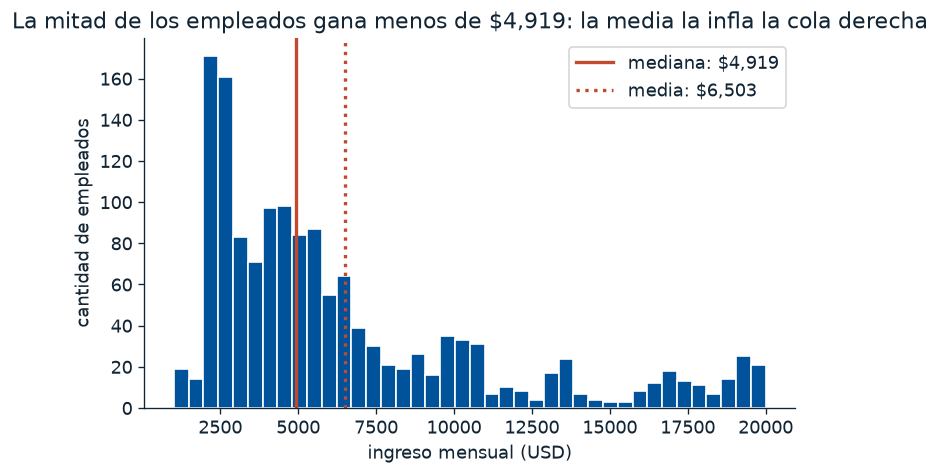

In [13]:
# Primera figura: la distribucion del ingreso mensual
plt.figure()
plt.hist(df["MonthlyIncome"], bins=40, color=COL["primary"], edgecolor="white")
plt.axvline(mediana_ingreso, color=COL["accent"], lw=2, label="mediana: $4,919")
plt.axvline(media_ingreso, color=COL["accent"], lw=2, ls=":", label="media: $6,503")
plt.title("La mitad de los empleados gana menos de $4,919: la media la infla la cola derecha")
plt.xlabel("ingreso mensual (USD)")
plt.ylabel("cantidad de empleados")
plt.legend()
guardar_figura("clase02_distribucion_ingreso")
plt.show()

<a name="s4"></a>
## 4. Procesamiento con pandas: filtrar, seleccionar, ordenar, agrupar

**La idea.** El 80% del trabajo real con datos son cuatro verbos que ya usaste en `dplyr`. El mapa completo:

| verbo | en `dplyr` (R) | en pandas |
|---|---|---|
| elegir columnas | `select(df, a, b)` | `df[["a", "b"]]` |
| filtrar filas | `filter(df, cond)` | `df[cond]` |
| ordenar | `arrange(df, desc(a))` | `df.sort_values("a", ascending=False)` |
| renombrar | `rename(df, nuevo = viejo)` | `df.rename(columns={"viejo": "nuevo"})` |
| crear columna | `mutate(df, c = a/b)` | `df["c"] = df["a"] / df["b"]` |
| agrupar y resumir | `group_by() + summarise()` | `df.groupby("g")["x"].median()` |

El filtro merece una pausa: `df["OverTime"] == "Yes"` produce una columna de `True`/`False` (una **mascara booleana**), y `df[mascara]` se queda con las filas donde es `True`. Es el `filter()` de R, en dos pasos visibles.

In [14]:
# Elegir columnas: la vista minima del problema
vista = df[["Age", "Department", "JobRole", "MonthlyIncome", "OverTime", "Attrition"]]
vista.head(3)

,Age,Department,JobRole,MonthlyIncome,OverTime,Attrition
0,41,Sales,Sales Executive,5993,Yes,Yes
1,49,Research & Development,Research Scientist,5130,No,No
2,37,Research & Development,Laboratory Technician,2090,Yes,Yes


In [15]:
# Filtrar filas: quienes hacen horas extra
mascara = df["OverTime"] == "Yes"
con_horas_extra = df[mascara]
print("Hacen horas extra:", len(con_horas_extra), "de", len(df))

# Ordenar: los 3 ingresos mas altos de ese grupo
top3 = con_horas_extra.sort_values("MonthlyIncome", ascending=False)
top3[["JobRole", "MonthlyIncome", "Attrition"]].head(3)

Hacen horas extra: 416 de 1470


,JobRole,MonthlyIncome,Attrition
568,Manager,19859,Yes
918,Manager,19847,No
1009,Research Director,19701,No


In [16]:
# Verificacion del filtro: 416 personas hacen horas extra
assert len(con_horas_extra) == 416
assert (con_horas_extra["OverTime"] == "Yes").all()

### Limpieza estructural: columnas sin informacion y duplicados

Tres columnas de este dataset valen lo mismo en las 1470 filas (`EmployeeCount`, `Over18`, `StandardHours`): no distinguen a nadie, asi que no aportan nada y conviene sacarlas. `nunique()` (cantidad de valores distintos) las delata. De paso chequeamos duplicados exactos con `duplicated()`: aca no hay, pero en datos reales (formularios enviados dos veces, uniones de tablas mal hechas) son moneda corriente.

In [17]:
# Detectar columnas constantes: un valor distinto en toda la columna
constantes = [c for c in df.columns if df[c].nunique() == 1]
print("Columnas constantes:", constantes)

# Sacarlas (axis="columns" indica que borramos columnas, no filas)
df = df.drop(columns=constantes)
print("Quedan", df.shape[1], "columnas")

# Duplicados exactos: filas identicas a otra anterior
print("Filas duplicadas:", df.duplicated().sum())

assert set(constantes) == {"EmployeeCount", "Over18", "StandardHours"}
assert df.shape == (1470, 32)
assert df.duplicated().sum() == 0

Columnas constantes: ['EmployeeCount', 'Over18', 'StandardHours']
Quedan 32 columnas
Filas duplicadas: 0


In [18]:
# Agrupar y resumir: ingreso mediano por departamento
ingreso_por_area = df.groupby("Department")["MonthlyIncome"].median().sort_values()
print(ingreso_por_area)

assert ingreso_por_area["Human Resources"] == 3886.0
assert ingreso_por_area["Research & Development"] == 4374.0
assert ingreso_por_area["Sales"] == 5754.5

Department
Human Resources           3886.0
Research & Development    4374.0
Sales                     5754.5
Name: MonthlyIncome, dtype: float64


<a name="e2"></a>
### Ejercicio 2. Pandas: donde se concentra la rotacion?

Calcula la **tasa de attrition por puesto** (`JobRole`) y mostra los 3 puestos con mayor rotacion. La receta: la columna `Attrition` vale `"Yes"`/`"No"`; convertila a booleana con `== "Yes"` y usa que **la media de una columna de True/False es una proporcion**. Despues agrupa por `JobRole` y ordena de mayor a menor.

*Pista: `df.groupby("JobRole")["EsYes"].mean()` te da la proporcion por grupo si antes creaste la columna booleana `EsYes`.*

In [19]:
df["AttritionBool"] = df["Attrition"] == "Yes"
tasa_por_puesto = df.groupby("JobRole")["AttritionBool"].mean().sort_values(ascending=False)

print(tasa_por_puesto.round(3).head(3))

assert abs(tasa_por_puesto.iloc[0] - 0.3976) < 1e-3
assert tasa_por_puesto.index[0] == "Sales Representative"
print("Ejercicio 2 correcto")

JobRole
Sales Representative     0.398
Laboratory Technician    0.239
Human Resources          0.231
Name: AttritionBool, dtype: float64
Ejercicio 2 correcto


Casi 4 de cada 10 representantes de ventas se van: cuando en la Clase 4 predigas attrition, el puesto va a ser una de las variables con mas señal. Eso es lo que busca el EDA: saber donde mirar antes de modelar.

<a name="s5"></a>
## 5. Datos faltantes y duplicados: detectar antes de decidir

**La idea.** Los datos reales llegan sucios: encuestas a medio responder, sensores que se apagan, exportaciones que duplican filas. La regla profesional es **primero detectar y entender el patron, despues decidir** que hacer; borrar a ciegas puede sesgar el analisis (si faltan justo los datos de quienes estan peor, tirarlos distorsiona todo).

> **Nota de laboratorio.** Este dataset viene limpio de fabrica, asi que para practicar vamos a ensuciar una **copia** con reglas fijas y a la vista (nada de azar: las mismas filas se ensucian en la version R, para que puedas comparar). Todo el analisis sustantivo de las otras secciones usa siempre los datos originales.

In [20]:
# Construir la copia "sucia": duplicados + faltantes con reglas deterministas
df_sucio = pd.concat([df, df.head(5)], ignore_index=True)   # 5 filas repetidas al final
print("Filas con duplicados:", len(df_sucio), "| duplicados detectados:", df_sucio.duplicated().sum())

df_sucio = df_sucio.drop_duplicates().reset_index(drop=True)
print("Tras eliminar duplicados:", len(df_sucio), "filas")

# Los enteros de numpy no admiten NaN: pasamos las columnas a float antes de agujerearlas
df_sucio["DistanceFromHome"] = df_sucio["DistanceFromHome"].astype("float64")
df_sucio["JobSatisfaction"] = df_sucio["JobSatisfaction"].astype("float64")

# Reglas fijas: se pierden datos segun el numero de legajo (EmployeeNumber)
df_sucio.loc[df_sucio["EmployeeNumber"] % 20 == 0, "DistanceFromHome"] = np.nan
df_sucio.loc[df_sucio["EmployeeNumber"] % 31 == 0, "JobSatisfaction"] = np.nan

assert df_sucio.shape[0] == 1470

Filas con duplicados: 1475 | duplicados detectados: 5
Tras eliminar duplicados: 1470 filas


In [21]:
# Detectar: cuantos faltantes hay, y donde
faltantes = df_sucio.isna().sum()
print(faltantes[faltantes > 0])
print("Total de celdas faltantes:", df_sucio.isna().sum().sum())

assert df_sucio["DistanceFromHome"].isna().sum() == 77
assert df_sucio["JobSatisfaction"].isna().sum() == 44
assert df_sucio.isna().sum().sum() == 121

DistanceFromHome    77
JobSatisfaction     44
dtype: int64
Total de celdas faltantes: 121


### Decidir: eliminar o imputar

Dos familias de estrategias, cada una con su costo:

- **Eliminar** (`dropna()`): simple y honesta, pero tira informacion; con 77 + 44 faltantes perderias hasta 121 filas de 1470, un 8%.
- **Imputar** (`fillna()`): rellenar con un valor razonable. Para una variable numerica asimetrica como la distancia, la **mediana** (robusta a outliers); para una ordinal como la satisfaccion, la **moda** (la categoria mas frecuente).

La eleccion depende de cuanto falta, de por que falta y de que vas a hacer despues. En la Clase 4 vas a ver la version para machine learning: la imputacion se aprende **solo del set de entrenamiento**, para no filtrar informacion del test.

In [22]:
# Imputar: mediana para la distancia, moda para la satisfaccion
mediana_dist = df_sucio["DistanceFromHome"].median()          # se calcula sin contar los NaN
moda_satisf = df_sucio["JobSatisfaction"].mode()[0]
print("Mediana de distancia:", mediana_dist, "| moda de satisfaccion:", moda_satisf)

df_imputado = df_sucio.copy()
df_imputado["DistanceFromHome"] = df_imputado["DistanceFromHome"].fillna(mediana_dist)
df_imputado["JobSatisfaction"] = df_imputado["JobSatisfaction"].fillna(moda_satisf)

print("Faltantes despues de imputar:", df_imputado.isna().sum().sum())

assert mediana_dist == 7.0 and moda_satisf == 4.0
assert df_imputado.isna().sum().sum() == 0
assert df_imputado["DistanceFromHome"].median() == 7.0  # la mediana no se movio

Mediana de distancia: 7.0 | moda de satisfaccion: 4.0
Faltantes despues de imputar: 0


<a name="e3"></a>
### Ejercicio 3. Faltantes: imputacion por grupo

Imputar con la mediana global es razonable, pero se puede afinar: la distancia al trabajo quiza difiere entre departamentos, y entonces conviene imputar cada faltante con la **mediana de su propio departamento**. Complete la imputacion por grupo usando `groupby` + `transform("median")`, que devuelve una columna alineada con el DataFrame donde cada fila lleva la mediana de su grupo.

*Pista: `df_sucio.groupby("Department")["DistanceFromHome"].transform("median")` produce la columna de medianas; usala como argumento de `fillna()`.*

In [23]:
mediana_por_depto = df_sucio.groupby("Department")["DistanceFromHome"].transform("median")
dist_imputada = df_sucio["DistanceFromHome"].fillna(mediana_por_depto)

print("Faltantes antes:", df_sucio["DistanceFromHome"].isna().sum(),
      "| despues:", dist_imputada.isna().sum())

assert dist_imputada.isna().sum() == 0
assert dist_imputada.median() == 7.0
print("Ejercicio 3 correcto")

Faltantes antes:

 77 | despues: 0
Ejercicio 3 correcto


<a name="s6"></a>
## 6. Outliers: atipico no es sinonimo de error

**La idea.** Un outlier es una observacion muy alejada del resto. La regla practica mas usada para señalarlos es la **regla del IQR**: es atipico lo que queda a mas de $1.5 \times IQR$ de los cuartiles,

$$ x > Q_3 + 1.5 \times IQR \qquad \text{o} \qquad x < Q_1 - 1.5 \times IQR $$

donde $Q_1$ y $Q_3$ son el primer y tercer cuartil (el 25% y el 75% de los datos quedan por debajo, respectivamente) e $IQR = Q_3 - Q_1$ es el rango intercuartilico, el ancho de la "caja central" que concentra la mitad de los datos.

> **La trampa clasica.** Detectar un outlier no autoriza a borrarlo. Un valor atipico puede ser un **error de carga** (una edad de 340) o un **caso real e informativo** (un director que gana 5 veces la mediana). Borrar outliers reales recorta justo la variabilidad que despues quiza quieras modelar. La regla: detectar con estadistica, decidir con conocimiento del dominio.

In [24]:
# Regla del IQR sobre el ingreso mensual
q1 = df["MonthlyIncome"].quantile(0.25)
q3 = df["MonthlyIncome"].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
print("Q1 =", q1, "| Q3 =", q3, "| IQR =", iqr, "| limite superior =", limite_superior)

outliers = df[df["MonthlyIncome"] > limite_superior]
print("Ingresos atipicos:", len(outliers), "de", len(df))

# Quienes son? Miramos su nivel jerarquico (JobLevel va de 1 a 5)
print("Nivel jerarquico de los atipicos:")
print(outliers["JobLevel"].value_counts().sort_index())

# Verificacion: son 114 y TODOS tienen nivel 4 o 5: gerentes y directores reales, no errores
assert q1 == 2911.0 and q3 == 8379.0 and limite_superior == 16581.0
assert len(outliers) == 114
assert outliers["JobLevel"].min() >= 4

Q1 = 2911.0 | Q3 = 8379.0 | IQR = 5468.0 | limite superior = 16581.0
Ingresos atipicos: 114 de 1470
Nivel jerarquico de los atipicos:
JobLevel
4    45
5    69
Name: count, dtype: int64


C:\Users\au805392\AppData\Local\Temp\ipykernel_29348\3630971869.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["MonthlyIncome"], vert=False, widths=0.5,


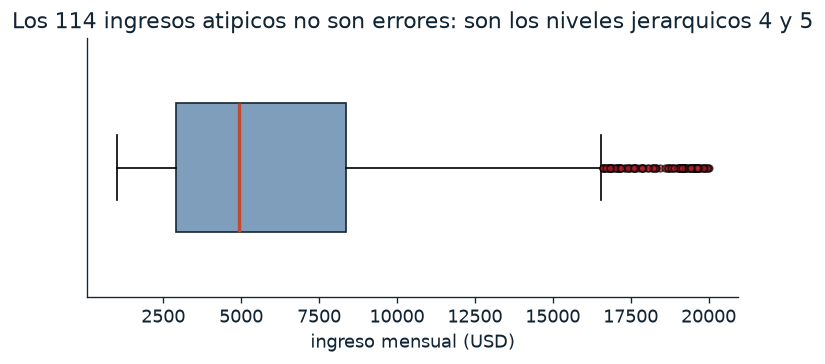

In [25]:
# El boxplot dibuja exactamente la regla del IQR: caja entre Q1 y Q3, atipicos como puntos
plt.figure(figsize=(7, 2.8))
plt.boxplot(df["MonthlyIncome"], vert=False, widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor=COL["muted"], color=COL["ink"]),
            medianprops=dict(color=COL["accent"], lw=2),
            flierprops=dict(marker="o", markerfacecolor=COL["bad"], markersize=4, alpha=0.6))
plt.title("Los 114 ingresos atipicos no son errores: son los niveles jerarquicos 4 y 5")
plt.xlabel("ingreso mensual (USD)")
plt.yticks([])
guardar_figura("clase02_outliers_ingreso")
plt.show()

### Laboratorio interactivo: que tan estricto es tu umbral?

El 1.5 de la regla es una convencion, no una ley. Move el multiplicador `k` y mira cuantos empleados quedan señalados como atipicos: con k mas chico la regla se vuelve paranoica, con k mas grande casi nadie es atipico. La leccion: "outlier" depende del umbral que elijas, y esa eleccion hay que reportarla.

In [26]:
#@title Laboratorio: umbral de outliers { display-mode: "form" }
import ipywidgets as W

# Referencia estatica (para lectura sin ejecutar): k = 1.5 -> 114 | k = 2.0 -> 76 | k = 3.0 -> 0
def _outliers_con_k(k):
    plt.figure(figsize=(7, 3.2))
    limite = q3 + k * iqr
    n_out = int((df["MonthlyIncome"] > limite).sum())
    plt.hist(df["MonthlyIncome"], bins=40, color=COL["muted"], edgecolor="white")
    plt.axvline(limite, color=COL["bad"], lw=2, label="limite: Q3 + " + str(k) + " x IQR")
    plt.title("Con k = " + str(k) + ", quedan señalados " + str(n_out) + " ingresos atipicos")
    plt.xlabel("ingreso mensual (USD)")
    plt.ylabel("empleados")
    plt.legend()
    plt.show()

k_slider = W.FloatSlider(value=1.5, min=1.0, max=3.0, step=0.25, description="k",
                         continuous_update=False)
display(W.VBox([k_slider, W.interactive_output(_outliers_con_k, {"k": k_slider})]))

<a name="s7"></a>
## 7. Agrupar para comparar y feature engineering

**La idea.** Las preguntas interesantes casi siempre comparan grupos: se van mas los que hacen horas extra? los que viajan seguido? El combo `groupby` + media de una columna booleana responde cualquier "tasa por grupo" en una linea. Y cuando ninguna columna existente captura el fenomeno, se **crea** una variable nueva con sentido sustantivo: eso es feature engineering, y la justificacion viene del dominio, no del algoritmo.

In [27]:
# La comparacion estrella de la clase: attrition segun horas extra
tasa_por_horas_extra = df.groupby("OverTime")["AttritionBool"].mean()
print((tasa_por_horas_extra * 100).round(1))

assert abs(tasa_por_horas_extra["No"] - 0.1044) < 1e-3
assert abs(tasa_por_horas_extra["Yes"] - 0.3053) < 1e-3

OverTime
No     10.4
Yes    30.5
Name: AttritionBool, dtype: float64


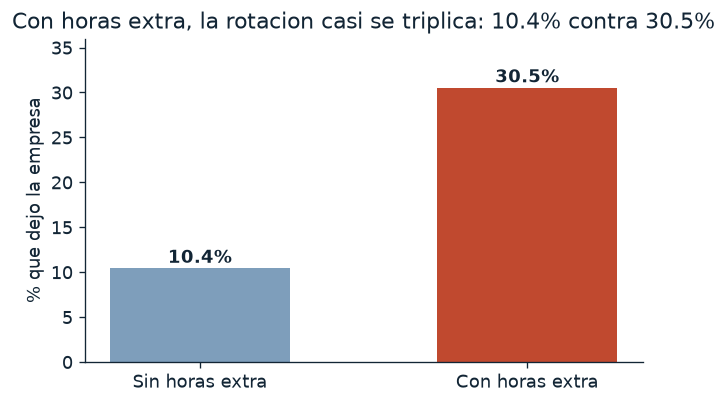

In [28]:
# Figura: la brecha en una imagen
plt.figure(figsize=(6, 3.5))
etiquetas = ["Sin horas extra", "Con horas extra"]
valores = [tasa_por_horas_extra["No"] * 100, tasa_por_horas_extra["Yes"] * 100]
barras = plt.bar(etiquetas, valores, color=[COL["muted"], COL["accent"]], width=0.55)
for barra, v in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width()/2, v + 0.6, str(round(v, 1)) + "%",
             ha="center", fontweight="bold")
plt.title("Con horas extra, la rotacion casi se triplica: 10.4% contra 30.5%")
plt.ylabel("% que dejo la empresa")
plt.ylim(0, 36)
guardar_figura("clase02_attrition_horas_extra")
plt.show()

In [29]:
# Otra comparacion con señal: viajar seguido por trabajo
tasa_por_viaje = df.groupby("BusinessTravel")["AttritionBool"].mean().sort_values()
print((tasa_por_viaje * 100).round(1))

assert abs(tasa_por_viaje["Travel_Frequently"] - 0.2491) < 1e-3
assert abs(tasa_por_viaje["Non-Travel"] - 0.0800) < 1e-3

BusinessTravel
Non-Travel            8.0
Travel_Rarely        15.0
Travel_Frequently    24.9
Name: AttritionBool, dtype: float64


### Crear variables con sentido: dos ejemplos

**Ingreso por año de experiencia.** Dos personas pueden ganar lo mismo con trayectorias muy distintas: 3000 dolares con 2 años de experiencia es una cosa, con 20 años es otra. El cociente captura esa diferencia (sumamos 1 al denominador para que quien recien empieza no divida por cero).

**Tramos de edad.** Para comparar generaciones conviene discretizar la edad en tramos con `pd.cut`, que corta una variable continua en intervalos con etiqueta.

In [30]:
# Feature 1: ingreso mensual por año de experiencia total
df["IngresoPorAnioExp"] = df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)

# Feature 2: tramos de edad
df["TramoEdad"] = pd.cut(df["Age"], bins=[17, 30, 40, 50, 61],
                         labels=["18-30", "31-40", "41-50", "51-60"])

tasa_por_tramo = df.groupby("TramoEdad", observed=True)["AttritionBool"].mean()
print("Tasa de attrition por tramo de edad:")
print((tasa_por_tramo * 100).round(1))

assert abs(df["IngresoPorAnioExp"].median() - 549.22) < 0.01
assert df["TramoEdad"].isna().sum() == 0            # todos los 1470 caen en un tramo
assert tasa_por_tramo["18-30"] > tasa_por_tramo["41-50"]  # los mas jovenes rotan mas

Tasa de attrition por tramo de edad:
TramoEdad
18-30    25.9
31-40    13.7
41-50    10.6
51-60    12.6
Name: AttritionBool, dtype: float64


<a name="e4"></a>
### Ejercicio 4. Feature engineering: el costo de viajar seguido

Crea la variable booleana `ViajaFrecuente` (si `BusinessTravel` es `"Travel_Frequently"`) y calcula la tasa de attrition de quienes viajan frecuente contra el resto. Te tiene que dar, aproximadamente, 24.9% contra 14.1%.

*Pista: es el mismo patron del Ejercicio 2: columna booleana + `groupby` + media.*

In [31]:
df["ViajaFrecuente"] = df["BusinessTravel"] == "Travel_Frequently"
tasa_viaje_frec = df.groupby("ViajaFrecuente")["AttritionBool"].mean()

print((tasa_viaje_frec * 100).round(1))

assert abs(tasa_viaje_frec[True] - 0.2491) < 1e-3
assert abs(tasa_viaje_frec[False] - 0.1408) < 1e-3
print("Ejercicio 4 correcto")

ViajaFrecuente
False    14.1
True     24.9
Name: AttritionBool, dtype: float64
Ejercicio 4 correcto


<a name="s8"></a>
## 8. Terminologia: hablar con precision

Hoy hiciste, sin nombrarlas, casi todas las etapas del vocabulario tecnico del programa. El mapa, para que cada termino te quede asociado a algo que ya hiciste:

| termino | que es | donde lo hiciste hoy |
|---|---|---|
| datos crudos | la fuente original, intacta | el CSV de IBM recien cargado |
| limpieza | corregir errores, duplicados, tipos | columnas constantes, duplicados (secciones 4 y 5) |
| procesamiento | manipular: filtrar, agrupar, resumir | mascaras booleanas, `groupby` (secciones 4 y 7) |
| preprocesamiento | lo que pide el algoritmo (estandarizar, codificar, imputar) | la imputacion (seccion 5); el resto llega en la Clase 4 |
| feature engineering | crear variables con sentido sustantivo | `IngresoPorAnioExp`, `TramoEdad`, `ViajaFrecuente` (seccion 7) |
| feature selection | elegir que variables entran al modelo | todavia no: llega con los modelos (Clases 4 a 7) |

La distincion no es pedanteria: cuando en la Clase 4 hablemos de *data leakage* vas a ver que confundir preprocesamiento con procesamiento puede invalidar un modelo entero.

<a name="quiz"></a>
## Autoevaluacion

Cuatro preguntas que cruzan toda la clase. Comprometete con una respuesta antes de abrir cada solucion.

**1.** `edades = [29, 41, 35]`. Que devuelve `edades[1]`?

<details><summary>Ver respuesta</summary>

`41`. Python cuenta desde 0: `edades[0]` es 29, `edades[1]` es 41. Este es el tropiezo mas comun viniendo de R, donde `edades[1]` seria 29.

</details>

**2.** La media del ingreso (6503) es mayor que la mediana (4919). Que te dice eso de la distribucion, y cual de las dos reportarias?

<details><summary>Ver respuesta</summary>

Asimetria a derecha: pocos ingresos muy altos arrastran la media hacia arriba. Para describir el ingreso "tipico" conviene la mediana, que no se deja arrastrar por la cola.

</details>

**3.** Encontraste 114 ingresos por encima de $Q_3 + 1.5 \times IQR$. Corresponde eliminarlos antes de modelar?

<details><summary>Ver respuesta</summary>

No sin investigarlos. En este dataset todos tienen nivel jerarquico 4 o 5: son gerentes y directores reales, informacion legitima, no errores de carga. Detectar es estadistica; decidir es conocimiento del dominio.

</details>

**4.** Para responder "que departamento tiene mayor tasa de rotacion" en una linea de pandas, que combinacion usas?

<details><summary>Ver respuesta</summary>

Columna booleana + agrupar + media: `df.groupby("Department")["AttritionBool"].mean()`. La media de una columna de True/False es una proporcion; ordenando el resultado ya tenes el ranking (da Sales con 20.6%).

</details>

<a name="cierre"></a>
## Cierre

**Lo que ya podes hacer.** Escribir Python basico (variables, listas, diccionarios, `for`, `if`, funciones); cargar un CSV desde la nube; explorar un dataset con `shape`, `info`, `describe` y `value_counts`; filtrar, ordenar, renombrar y agrupar; detectar y tratar duplicados, faltantes (eliminar o imputar, global o por grupo) y outliers (regla del IQR mas criterio de dominio); y crear variables nuevas con sentido sustantivo. Es exactamente la caja de herramientas que un EDA profesional usa a diario.

**El hallazgo sustantivo de hoy**, por si te lo llevas en una frase: en esta empresa la rotacion se concentra en la gente que hace horas extra (30.5% contra 10.4%), viaja seguido (24.9%) y esta en ventas (39.8% entre representantes). En la Clase 4 vamos a intentar predecirla.

**Para seguir.**

- McKinney, *Python for Data Analysis*, caps. 5 a 7: la referencia directa de todo lo que usaste hoy ([gratis online](https://wesmckinney.com/book/)).
- Wickham y Grolemund, *R para Ciencia de Datos*, caps. 4 a 6, si queres el espejo en R ([gratis online](https://es.r4ds.hadley.nz/)).
- La notebook R equivalente de esta clase, en el sitio de la materia.

## Apendice: Machete de pandas en una pantalla

| tarea | codigo |
|---|---|
| cargar CSV desde URL | `pd.read_csv(url)` |
| dimensiones / tipos / resumen | `df.shape`, `df.info()`, `df.describe()` |
| contar categorias | `df["col"].value_counts()` |
| elegir columnas | `df[["a", "b"]]` |
| filtrar filas | `df[df["col"] == valor]` |
| ordenar | `df.sort_values("col", ascending=False)` |
| renombrar | `df.rename(columns={"viejo": "nuevo"})` |
| columnas constantes | `df["col"].nunique() == 1` |
| duplicados | `df.duplicated().sum()`, `df.drop_duplicates()` |
| faltantes | `df.isna().sum()`, `df.dropna()`, `df["c"].fillna(valor)` |
| imputar por grupo | `df.groupby("g")["c"].transform("median")` |
| outliers (IQR) | `q3 + 1.5 * (q3 - q1)` |
| tasa por grupo | `df.groupby("g")["bool"].mean()` |
| crear variable | `df["nueva"] = expresion` |
| discretizar | `pd.cut(df["col"], bins=[...], labels=[...])` |

---
**Correr / compartir esta notebook.** Abrila en Google Colab con el boton del inicio y elegi *Entorno de ejecucion → Ejecutar todo*; no hace falta instalar nada.

*Datos: IBM HR Analytics Employee Attrition (datos ficticios creados por IBM), servidos desde el [repositorio oficial de IBM](https://github.com/IBM/employee-attrition-aif360). Cada numero de esta pagina se recalcula y verifica con asserts al ejecutar.*